# 열처리 공정최적화 AI 데이터셋 - 선형회귀 베이스라인 파이프라인

KAMP(중소벤처기업부 · KAIST) "열처리 공정최적화 AI 데이터셋"을 활용한 2026년도
K-인공지능 제조데이터 경진대회 준비용 연습 노트북입니다.

**이 노트북에서 하는 일**
1. `raw_total_data.csv`(원본)와 `품질전처리후데이터.csv`(품질전처리 후) 비교
2. `label.xlsx`와의 연관관계 분석 (배정번호 기준 병합)
3. 전처리 파이프라인 구축 (배정번호별 min/max 집계, 다중공선성 제거, 불량비율 파생변수 생성)
4. Train : Val : Test = 8 : 1 : 1 분할 (**Test는 맨 마지막 '최종 평가' 셀 전까지 절대 열어보지 않습니다**)
5. 선형회귀(Linear Regression) 베이스라인 모델 학습 + 평가 + 지표 시각화
6. 전체 파이프라인 완료 후 최종 EDA 및 Feature Importance 분석

> **⚠️ 참고**: 이 노트북은 `../dataset/raw_total_data.csv`, `../dataset/품질전처리후데이터.csv`,
> `../dataset/label.xlsx` 파일이 로컬(사용자 PC)에 존재해야 실행됩니다. 파일 용량이 커서
> (raw 약 481MB, 품질전처리후 약 502MB) 지금은 클라우드 작업공간으로 옮길 수 없어 코드/구조만
> 먼저 작성했습니다. 로컬 가상환경(`.venv`)에서 Jupyter로 이 노트북을 열어 순서대로 실행해
> 주세요. (`requirements.txt` 참고)


In [24]:
# ===== 0. 환경 설정 =====
# - 필요한 라이브러리 불러오기
# - 경고 메시지 숨기기 (버전 차이로 인한 무의미한 경고 제거)
# - 재현성을 위한 랜덤 시드 고정
# - 데이터 / 체크포인트 / 그림 저장 경로 설정
# - 한글 폰트(나눔고딕) 설정 (그래프 한글 깨짐 방지)
import os
import sys
import warnings

warnings.filterwarnings(action="ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

# src/training_utils.py 를 import 할 수 있도록 경로 추가
sys.path.append(os.path.abspath(os.path.join("..", "src")))
import training_utils as tu

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = os.path.join("..", "dataset")
PROCESSED_DIR = os.path.join("..", "data_processed")
CHECKPOINT_DIR = os.path.join("..", "checkpoints")
FIGURE_DIR = os.path.join("..", "figures")
for d in (PROCESSED_DIR, CHECKPOINT_DIR, FIGURE_DIR):
    os.makedirs(d, exist_ok=True)

sns.set_theme(style="whitegrid")

# 그래프 한글 깨짐 방지 (나눔고딕 폰트 적용, 설치 안 되어 있으면 설치 안내 출력)
tu.set_korean_font("NanumGothic")

print("환경 설정 완료. RANDOM_STATE =", RANDOM_STATE)


[한글 폰트] 'NanumGothicOTF' 적용 완료.
환경 설정 완료. RANDOM_STATE = 42


## 1. 데이터 로드 및 원본(raw) vs 품질전처리 후 데이터 비교

`raw_total_data.csv`(원본, 약 294만 행)와 `품질전처리후데이터.csv`(품질전처리 완료본)를
불러와 스키마 · 결측치 · 행 수 · 메모리 사용량 관점에서 어떤 차이가 있는지 확인합니다.

파일이 매우 크므로(수백 MB) 처음 로드에는 다소 시간이 걸릴 수 있습니다.


In [25]:
# ===== 1-1. 원본 데이터 / 품질전처리 후 데이터 불러오기 =====
# 가이드북 안내대로 한글 컬럼명 인코딩 문제를 피하기 위해 encoding='utf-8-sig' 사용
print("원본 데이터(raw_total_data.csv) 로딩 중 ...")
df_raw = pd.read_csv(os.path.join(DATA_DIR, "raw_total_data.csv"), encoding="utf-8-sig")
print(f"  -> shape: {df_raw.shape}")

print("품질전처리 후 데이터(품질전처리후데이터.csv) 로딩 중 ...")
df_clean = pd.read_csv(os.path.join(DATA_DIR, "품질전처리후데이터.csv"), encoding="utf-8-sig")
print(f"  -> shape: {df_clean.shape}")


원본 데이터(raw_total_data.csv) 로딩 중 ...
  -> shape: (2939722, 20)
품질전처리 후 데이터(품질전처리후데이터.csv) 로딩 중 ...
  -> shape: (2939722, 21)


In [26]:
# ===== 1-2. 스키마(컬럼/행 수/메모리) 비교 =====
schema_summary, dtype_diff = tu.compare_schema(df_raw, df_clean)

print("=== 스키마 요약 ===")
for k, v in schema_summary.items():
    print(f"  {k}: {v}")

print()
print("=== 컬럼별 dtype 비교 (dtype 이 바뀐 컬럼만 표시) ===")
display(dtype_diff[dtype_diff["dtype_changed"]])


=== 스키마 요약 ===
  raw_shape: (2939722, 20)
  clean_shape: (2939722, 21)
  raw_memory_MB: 670.26
  clean_memory_MB: 693.77
  columns_only_in_raw: []
  columns_only_in_clean: ['Unnamed: 0']
  row_count_diff: 0

=== 컬럼별 dtype 비교 (dtype 이 바뀐 컬럼만 표시) ===


,column,raw_dtype,clean_dtype,dtype_changed


,column,raw_missing_count,raw_missing_pct,clean_missing_count,clean_missing_pct,in_raw_only,in_clean_only
0,TAG_MIN,0.0,0.000000,0,0.000000,False,False
1,Unnamed: 0,NaN,NaN,0,0.000000,False,True
2,건조 1존 OP,1.0,0.000034,1,0.000034,False,False
3,건조 2존 OP,1.0,0.000034,1,0.000034,False,False
4,건조로 온도 1 Zone,116.0,0.003946,116,0.003946,False,False
5,건조로 온도 2 Zone,148.0,0.005034,148,0.005034,False,False
6,배정번호,0.0,0.000000,0,0.000000,False,False
7,세정기,91.0,0.003096,91,0.003096,False,False
8,소입1존 OP,4288.0,0.145864,4288,0.145864,False,False
9,소입2존 OP,0.0,0.000000,0,0.000000,False,False


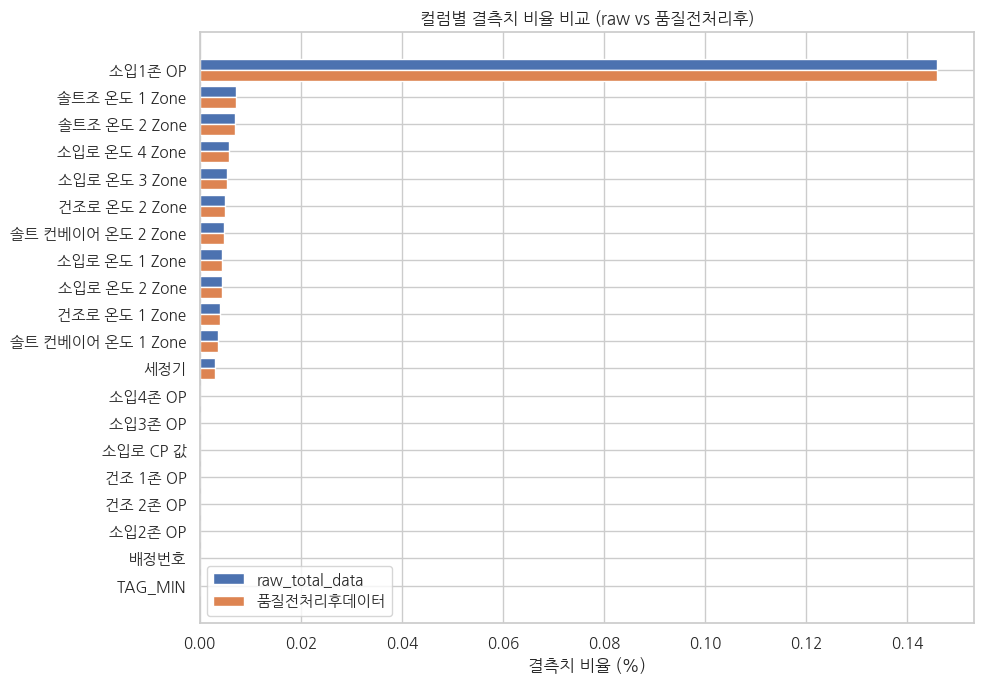

In [27]:
# ===== 1-3. 결측치 비교 =====
missing_cmp = tu.compare_missing(df_raw, df_clean)
display(missing_cmp)

fig = tu.plot_missing_comparison(missing_cmp)
fig.savefig(os.path.join(FIGURE_DIR, "01_missing_comparison.png"), dpi=150)
plt.show()


In [28]:
# ===== 1-4. 배정번호(batch id) 개수 및 기간 비교 =====
print("raw_total_data 고유 배정번호 개수  :", df_raw["배정번호"].nunique())
print("품질전처리후데이터 고유 배정번호 개수:", df_clean["배정번호"].nunique())

if "TAG_MIN" in df_raw.columns:
    raw_time = pd.to_datetime(df_raw["TAG_MIN"], errors="coerce")
    print("raw_total_data 수집 기간          :", raw_time.min(), "~", raw_time.max())
if "TAG_MIN" in df_clean.columns:
    clean_time = pd.to_datetime(df_clean["TAG_MIN"], errors="coerce")
    print("품질전처리후데이터 수집 기간       :", clean_time.min(), "~", clean_time.max())


raw_total_data 고유 배정번호 개수  : 136
품질전처리후데이터 고유 배정번호 개수: 136
raw_total_data 수집 기간          : 2022-01-03 11:22:07 ~ 2022-07-19 19:08:59
품질전처리후데이터 수집 기간       : 2022-01-03 11:22:07 ~ 2022-07-19 19:08:59


**해석 메모 (실행 후 결과를 보고 아래 내용을 채워 넣으세요)**

- 행 수 차이: (예: 결측치 제거로 인해 N행 감소 / 혹은 변화 없음)
- 컬럼 차이: (raw 에만 있는 컬럼, 품질전처리 후에만 있는 컬럼)
- dtype 차이: (예: TAG_MIN 이 문자열 → datetime 으로 변환됨)
- 결측치: (품질전처리 후 결측치가 얼마나 감소했는지)


## 2. label.xlsx 와의 연관관계 분석

`label.xlsx`는 배정번호(batch id) 별 양품수량/불량수량 등 품질검사 결과를 담고 있습니다.
센서 데이터(품질전처리후데이터)를 배정번호 단위로 집계한 뒤 라벨과 병합하여 연관관계를 살펴봅니다.


In [29]:
# ===== 2-1. label.xlsx 로드 =====
df_label = pd.read_excel(os.path.join(DATA_DIR, "label.xlsx"))
print("label shape:", df_label.shape)
display(df_label.head())
display(df_label.describe(include="all").T)


label shape: (136, 22)


,배정번호,작업일,공정명,설비명,작업자,품번,품명,LOT NO.,양품수량,불량수량,...,원소재,변형(폭),내폭,외폭,형상파손,경도,인장경도,초도품,TEST,경도측정
0,102410,2022-01-03,열처리,열처리 염욕_1,최명수,(AT)560050622D,"(AT)CHANNEL, K12A, STOP",HYM30,15160,3,...,0,0,3,0,0,0,0,0,0,0
1,102585,2022-01-03,열처리,열처리 염욕_1,이상수,(AT)560050622D,"(AT)CHANNEL, K12A, STOP",HZA01,29892,10,...,0,0,10,0,0,0,0,0,0,0
2,102930,2022-01-04,열처리,열처리 염욕_1,박창용,(AT)560050622D,"(AT)CHANNEL, K12A, STOP",HZA01,59616,30,...,0,0,30,0,0,0,0,0,0,0
3,103142,2022-01-05,열처리,열처리 염욕_1,최명수,(AT)560050622D,"(AT)CHANNEL, K12A, STOP",HZA02,74730,13,...,0,0,13,0,0,0,0,0,0,0
4,103675,2022-01-06,열처리,열처리 염욕_1,최명수,(AT)560050622D,"(AT)CHANNEL, K12A, STOP",HZA02,14979,2,...,0,0,2,0,0,0,0,0,0,0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
배정번호,136.0,NaN,NaN,NaN,128897.191176,102410.0,120467.75,130199.0,138982.5,148069.0,12403.393924
작업일,136,NaN,NaN,NaN,2022-04-21 10:35:17.647058944,2022-01-03 00:00:00,2022-03-15 18:00:00,2022-04-23 00:00:00,2022-06-03 12:00:00,2022-07-19 00:00:00,NaN
공정명,136,1,열처리,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
설비명,136,1,열처리 염욕_1,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
작업자,136,7,이상수,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
품번,136,1,(AT)560050622D,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
품명,136,1,"(AT)CHANNEL, K12A, STOP",136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LOT NO.,136,86,HZE06,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
양품수량,136.0,NaN,NaN,NaN,45012.301471,8412.0,29736.0,44003.0,60120.75,104740.0,25548.197992
불량수량,136.0,NaN,NaN,NaN,15.117647,0.0,4.0,8.5,17.0,120.0,18.549657


,배정번호,양품수량,불량수량,불량비율
0,102410,15160,3,0.019785
1,102585,29892,10,0.033443
2,102930,59616,30,0.050297
3,103142,74730,13,0.017393
4,103675,14979,2,0.013350


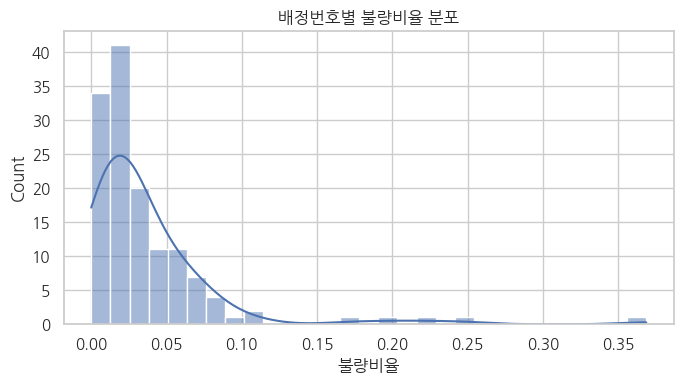

In [30]:
# ===== 2-2. 불량비율(%) 파생변수 생성 =====
# 불량비율 = 불량수량 / (불량수량 + 양품수량) * 100
df_label = tu.make_defect_rate(df_label)
display(df_label[["배정번호", "양품수량", "불량수량", "불량비율"]].head())

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df_label["불량비율"], kde=True, ax=ax)
ax.set_title("배정번호별 불량비율 분포")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "02_defect_rate_distribution.png"), dpi=150)
plt.show()


In [31]:
# ===== 2-3. 센서 데이터를 배정번호 단위로 집계 (min/max) =====
# 품질전처리후데이터(이미 정제된 데이터)를 기준으로 집계한다.
df_agg = tu.aggregate_min_max(df_clean, id_col="배정번호", time_col="TAG_MIN")
print("배정번호 단위 집계 결과 shape:", df_agg.shape)
display(df_agg.head())


배정번호 단위 집계 결과 shape: (136, 39)


,배정번호,Unnamed: 0_min,건조 1존 OP_min,건조 2존 OP_min,건조로 온도 1 Zone_min,건조로 온도 2 Zone_min,세정기_min,소입1존 OP_min,소입2존 OP_min,소입3존 OP_min,...,소입4존 OP_max,소입로 CP 값_max,소입로 온도 1 Zone_max,소입로 온도 2 Zone_max,소입로 온도 3 Zone_max,소입로 온도 4 Zone_max,솔트 컨베이어 온도 1 Zone_max,솔트 컨베이어 온도 2 Zone_max,솔트조 온도 1 Zone_max,솔트조 온도 2 Zone_max
0,102410,0,55.8907,7.84754,97.8385,98.4388,68.2865,0.039724,52.8176,45.4223,...,80.3567,0.505652,870.536,861.258,860.889,862.014,295.967,288.406,329.293,329.300
1,102585,7342,55.4900,5.02241,97.9840,98.5958,67.6928,0.013098,48.3596,45.5750,...,81.8909,0.470900,871.084,861.795,860.874,861.513,296.437,290.651,329.343,329.121
2,102930,20641,53.9100,7.32836,97.7743,98.5116,67.3211,0.011148,36.0278,41.2264,...,78.8885,0.473188,869.805,861.587,861.064,861.865,297.002,289.902,329.443,329.383
3,103142,47623,55.6307,7.47999,98.3127,98.1810,67.1142,0.169279,39.7968,42.9381,...,80.9559,0.473631,869.918,860.839,860.768,861.752,296.633,290.161,329.380,329.267
4,103675,79352,52.9816,7.21693,97.7285,98.4935,67.8759,0.001077,40.2626,43.5947,...,81.6436,0.463701,872.031,860.924,861.067,862.106,295.982,287.750,329.261,329.320


In [32]:
# ===== 2-4. 라벨 데이터와 병합 =====
label_subset = df_label[["배정번호", "양품수량", "불량수량", "불량비율"]]
df_total = pd.merge(label_subset, df_agg, on="배정번호", how="inner")
print("병합 후 df_total shape:", df_total.shape)
print("(label 136행 중 센서 데이터와 매칭된 배정번호 수:", df_total.shape[0], ")")
display(df_total.head())

df_total.to_csv(os.path.join(PROCESSED_DIR, "df_total.csv"), index=False, encoding="utf-8-sig")


병합 후 df_total shape: (136, 42)
(label 136행 중 센서 데이터와 매칭된 배정번호 수: 136 )


,배정번호,양품수량,불량수량,불량비율,Unnamed: 0_min,건조 1존 OP_min,건조 2존 OP_min,건조로 온도 1 Zone_min,건조로 온도 2 Zone_min,세정기_min,...,소입4존 OP_max,소입로 CP 값_max,소입로 온도 1 Zone_max,소입로 온도 2 Zone_max,소입로 온도 3 Zone_max,소입로 온도 4 Zone_max,솔트 컨베이어 온도 1 Zone_max,솔트 컨베이어 온도 2 Zone_max,솔트조 온도 1 Zone_max,솔트조 온도 2 Zone_max
0,102410,15160,3,0.019785,0,55.8907,7.84754,97.8385,98.4388,68.2865,...,80.3567,0.505652,870.536,861.258,860.889,862.014,295.967,288.406,329.293,329.300
1,102585,29892,10,0.033443,7342,55.4900,5.02241,97.9840,98.5958,67.6928,...,81.8909,0.470900,871.084,861.795,860.874,861.513,296.437,290.651,329.343,329.121
2,102930,59616,30,0.050297,20641,53.9100,7.32836,97.7743,98.5116,67.3211,...,78.8885,0.473188,869.805,861.587,861.064,861.865,297.002,289.902,329.443,329.383
3,103142,74730,13,0.017393,47623,55.6307,7.47999,98.3127,98.1810,67.1142,...,80.9559,0.473631,869.918,860.839,860.768,861.752,296.633,290.161,329.380,329.267
4,103675,14979,2,0.013350,79352,52.9816,7.21693,97.7285,98.4935,67.8759,...,81.6436,0.463701,872.031,860.924,861.067,862.106,295.982,287.750,329.261,329.320


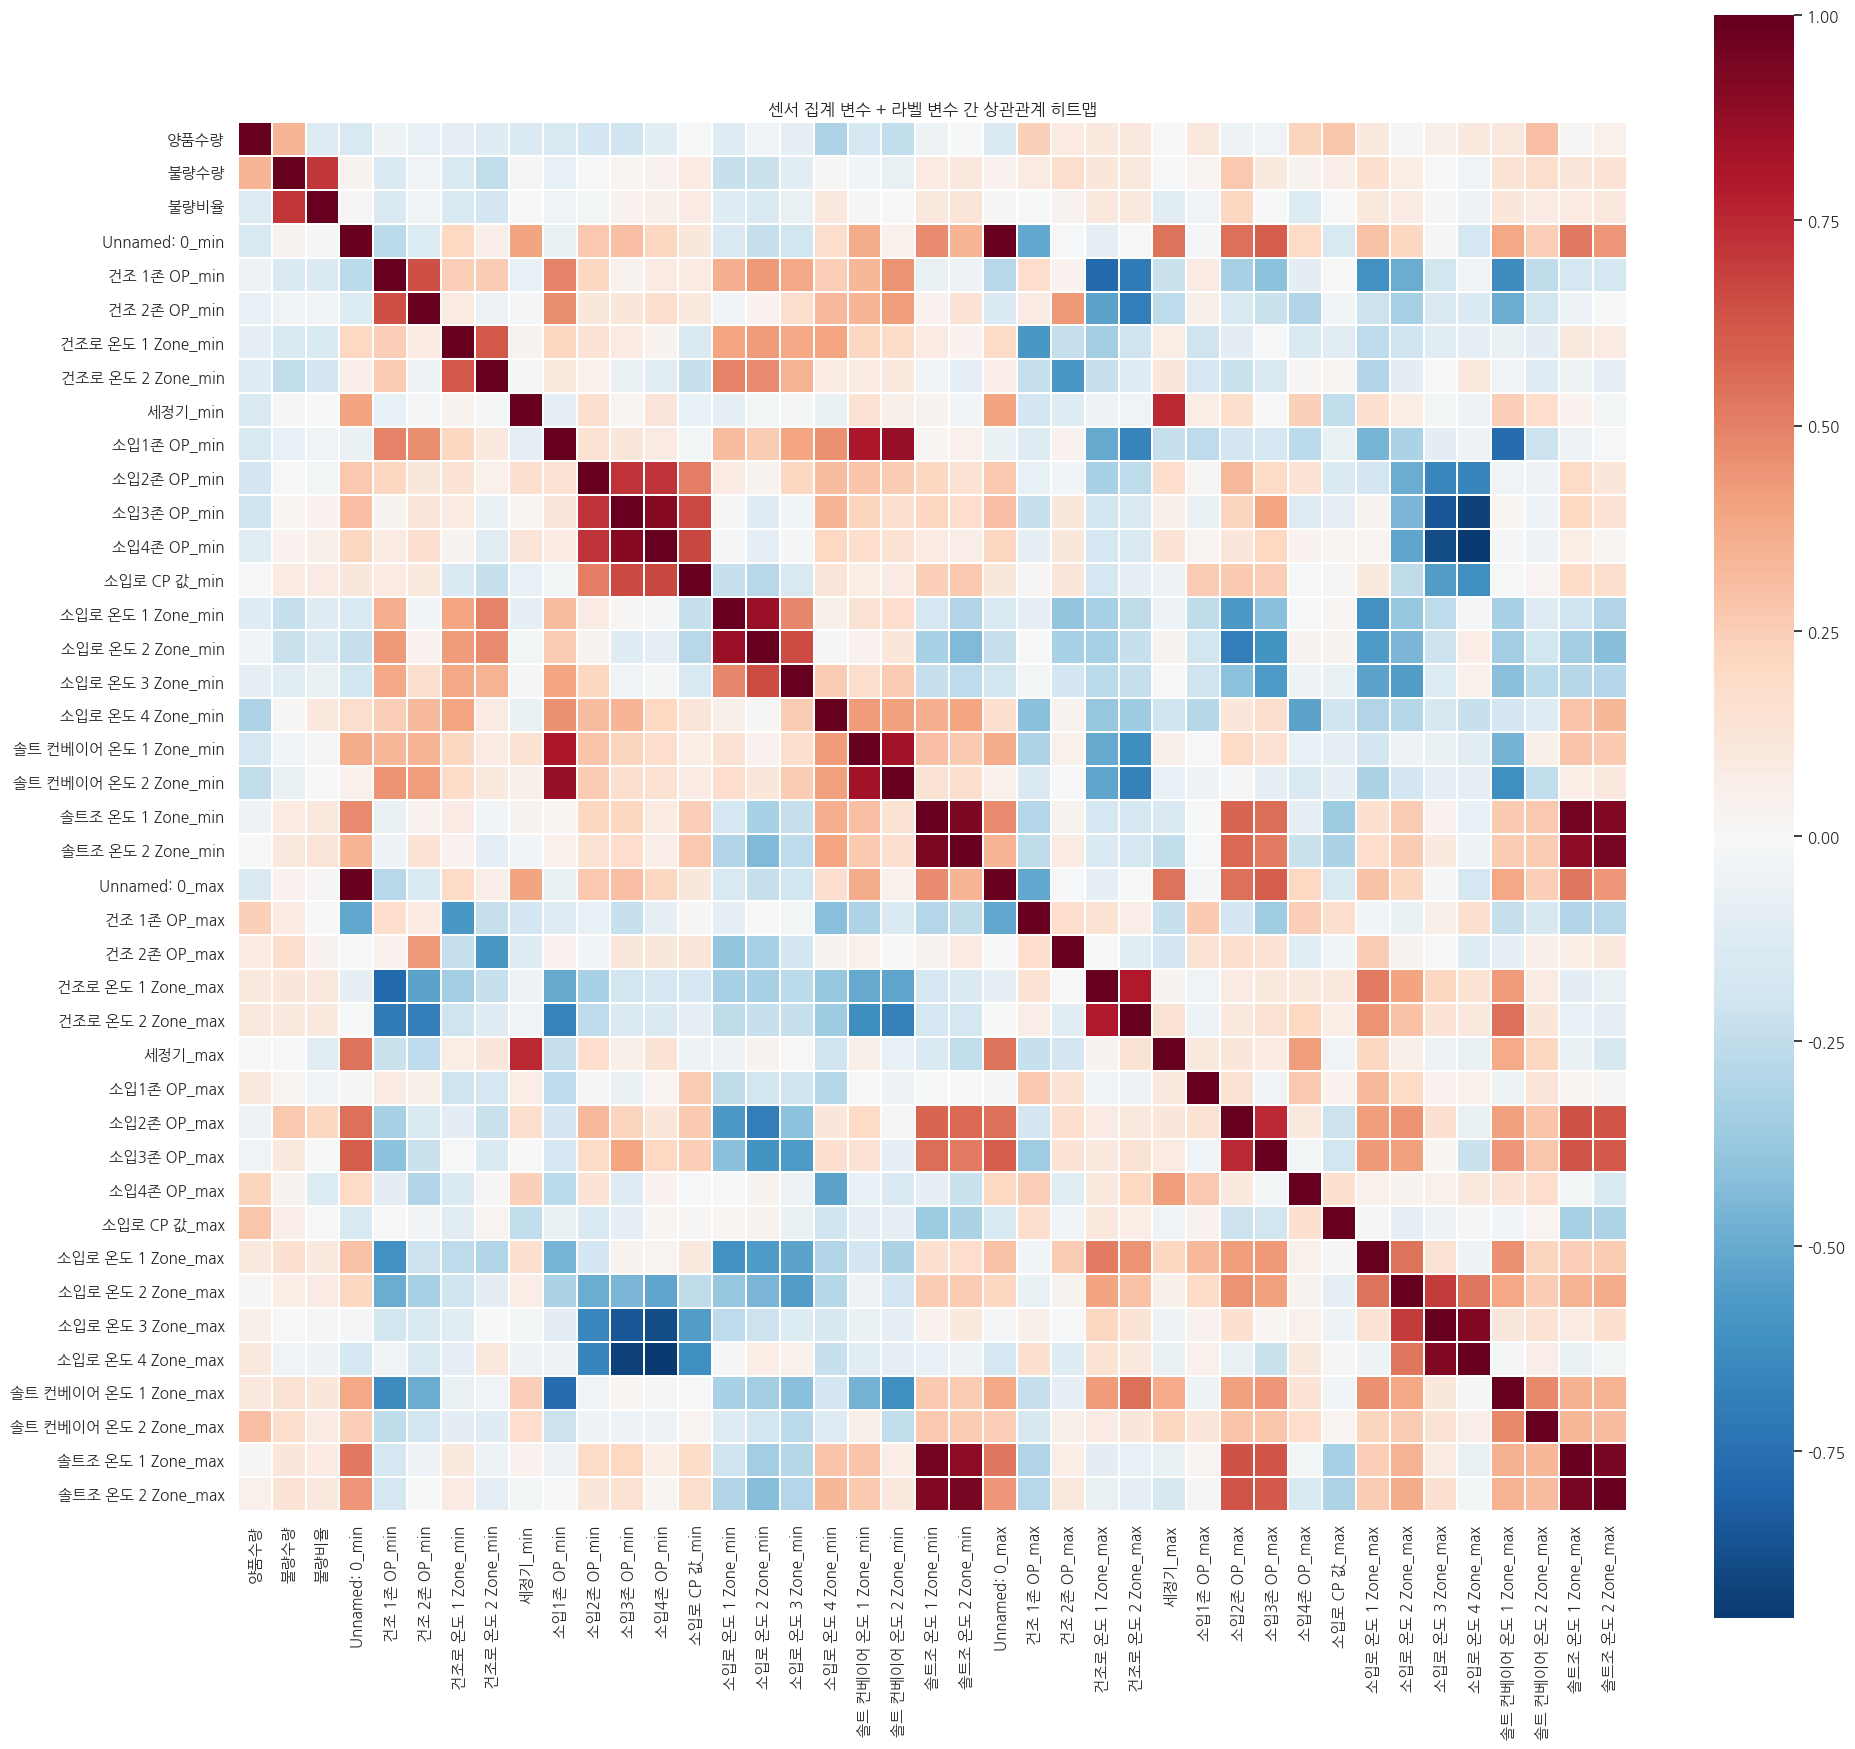

불량비율과 상관관계가 높은 변수 Top 15 (절대값 기준)


불량비율                     1.000000
불량수량                     0.716062
소입2존 OP_max              0.211151
건조로 온도 2 Zone_min        0.188119
건조로 온도 1 Zone_min        0.153715
소입로 온도 2 Zone_min        0.149948
건조 1존 OP_min             0.143082
소입4존 OP_max              0.131049
양품수량                     0.127258
솔트조 온도 2 Zone_min        0.124905
소입로 온도 1 Zone_min        0.118954
솔트 컨베이어 온도 1 Zone_max    0.114975
세정기_max                  0.112219
소입로 온도 4 Zone_min        0.104702
솔트조 온도 1 Zone_min        0.103407
솔트조 온도 2 Zone_max        0.101177
Name: 불량비율, dtype: float64

In [33]:
# ===== 2-5. 연관관계(상관관계) 시각화 =====
# 배정번호는 식별자이므로 상관관계 분석에서 제외한다.
corr_df = df_total.drop(columns=["배정번호"])
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=False, cmap="RdBu_r", center=0, square=True,
            linewidths=0.3, ax=ax)
ax.set_title("센서 집계 변수 + 라벨 변수 간 상관관계 히트맵")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "03_full_correlation_heatmap.png"), dpi=150)
plt.show()

print("불량비율과 상관관계가 높은 변수 Top 15 (절대값 기준)")
display(corr_matrix["불량비율"].abs().sort_values(ascending=False).head(16))


## 3. 전처리 파이프라인: 다중공선성 제거 + 독립/종속변수 분리

센서 변수 중 서로 상관관계가 매우 높은(다중공선성) 변수쌍이 존재하면 선형회귀 계수 해석이
왜곡될 수 있습니다. 상관계수 절대값이 0.8 이상인 변수쌍 중 하나를 반복적으로 제거합니다.


In [34]:
# ===== 3-1. 독립변수(X) / 종속변수(y) 분리 =====
# 배정번호(식별자), 양품수량/불량수량(불량비율 계산에 이미 사용됨), 불량비율(목표변수)은
# 독립변수에서 제외한다.
X_full = df_total.drop(columns=["배정번호", "양품수량", "불량수량", "불량비율"])
y_full = df_total["불량비율"]

print("전처리 전 독립변수 개수:", X_full.shape[1])


전처리 전 독립변수 개수: 38


In [35]:
# ===== 3-2. 다중공선성이 높은 변수 제거 (상관계수 |r| >= 0.8) =====
X_reduced, drop_log = tu.remove_multicollinear_features(X_full, threshold=0.8)

print(f"제거된 변수 수: {len(drop_log)} / 남은 변수 수: {X_reduced.shape[1]}")
print()
print("=== 제거 로그 (제거된 변수, 남긴 변수, 상관계수) ===")
for row in drop_log:
    print(f"  - {row['dropped']!r} 제거 (↔ {row['kept']!r}, r={row['correlation']:.3f})")


제거된 변수 수: 11 / 남은 변수 수: 27

=== 제거 로그 (제거된 변수, 남긴 변수, 상관계수) ===
  - 'Unnamed: 0_min' 제거 (↔ 'Unnamed: 0_max', r=1.000)
  - '솔트조 온도 1 Zone_max' 제거 (↔ '솔트조 온도 1 Zone_min', r=0.961)
  - '소입4존 OP_min' 제거 (↔ '소입로 온도 4 Zone_max', r=0.953)
  - '솔트조 온도 2 Zone_max' 제거 (↔ '솔트조 온도 2 Zone_min', r=0.952)
  - '솔트조 온도 2 Zone_min' 제거 (↔ '솔트조 온도 1 Zone_min', r=0.932)
  - '소입3존 OP_min' 제거 (↔ '소입로 온도 4 Zone_max', r=0.924)
  - '소입로 온도 3 Zone_max' 제거 (↔ '소입로 온도 4 Zone_max', r=0.923)
  - '소입1존 OP_min' 제거 (↔ '솔트 컨베이어 온도 2 Zone_min', r=0.868)
  - '소입로 온도 2 Zone_min' 제거 (↔ '소입로 온도 1 Zone_min', r=0.862)
  - '솔트 컨베이어 온도 2 Zone_min' 제거 (↔ '솔트 컨베이어 온도 1 Zone_min', r=0.840)
  - '건조로 온도 1 Zone_max' 제거 (↔ '건조로 온도 2 Zone_max', r=0.801)


## 4. Train : Val : Test = 8 : 1 : 1 분할

**★ 매우 중요 ★** 아래에서 분리되는 `X_test`, `y_test` 는 노트북 맨 마지막 "최종 테스트
평가" 섹션 전까지 **어떤 셀에서도 조회·시각화·스케일링 fit 에 사용하지 않습니다.**
(EDA, 스케일러 fit, 모델 학습/튜닝은 모두 train/val 만 사용)


In [36]:
# ===== 4-1. 8:1:1 분할 =====
split = tu.split_train_val_test(X_reduced, y_full, ratios=(0.8, 0.1, 0.1), random_state=RANDOM_STATE)
X_train, X_val, X_test = split["X_train"], split["X_val"], split["X_test"]
y_train, y_val, y_test = split["y_train"], split["y_val"], split["y_test"]

print(f"train: {X_train.shape[0]}개  ({X_train.shape[0] / len(df_total):.1%})")
print(f"val  : {X_val.shape[0]}개  ({X_val.shape[0] / len(df_total):.1%})")
print(f"test : {X_test.shape[0]}개  ({X_test.shape[0] / len(df_total):.1%})  <- 최종 평가 전까지 미사용")

# 재현성을 위해 분할 인덱스를 저장해 둔다 (다음 실행에서도 동일한 분할 재현 가능)
X_train.to_csv(os.path.join(PROCESSED_DIR, "X_train.csv"), index=True, encoding="utf-8-sig")
X_val.to_csv(os.path.join(PROCESSED_DIR, "X_val.csv"), index=True, encoding="utf-8-sig")
X_test.to_csv(os.path.join(PROCESSED_DIR, "X_test_DO_NOT_OPEN.csv"), index=True, encoding="utf-8-sig")


train: 108개  (79.4%)
val  : 14개  (10.3%)
test : 14개  (10.3%)  <- 최종 평가 전까지 미사용


In [37]:
# ===== 4-2. 정규화(MinMaxScaler) - train 데이터에만 fit =====
# 스케일러는 반드시 train 데이터에만 fit 하고, val/test 는 transform 만 적용한다.
# (test 에 fit 하면 '미래 정보 누수'가 발생하므로 절대 금지)
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
# X_test 는 이 시점에 transform 하지 않는다. (최종 평가 셀에서만 transform)

feature_names = X_reduced.columns.tolist()
print("스케일링 완료. 사용할 최종 독립변수 개수:", len(feature_names))


스케일링 완료. 사용할 최종 독립변수 개수: 27


## 5. 모델 학습: 선형회귀 베이스라인

두 가지 방식으로 선형회귀를 학습합니다.

1. **`LinearRegression`** (scikit-learn) : 최소제곱법으로 한 번에 계산되는 표준 베이스라인
   (가이드북과 동일한 방식). 데이터가 적어(100여 개) 즉시 학습됩니다.
2. **`SGDRegressor`(반복학습)** : 동일한 선형모델을 epoch 단위로 반복 학습시키며,
   - 진행 상황을 progress bar(tqdm)로 표시하고
   - 매 N epoch 마다 체크포인트를 저장하여, 학습이 중간에 끊겨도 이어서(resume) 학습할 수
     있도록 구현했습니다. (`training_utils.CheckpointManager`,
     `training_utils.train_sgd_regressor_with_checkpoint`)

최종 성능/해석(계수)은 두 모델을 비교하여 선택합니다.


In [38]:
# ===== 5-1. LinearRegression 베이스라인 (closed-form, 즉시 학습) =====
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("LinearRegression 학습 완료 (최소제곱법으로 즉시 수렴)")


LinearRegression 학습 완료 (최소제곱법으로 즉시 수렴)


In [39]:
# ===== 5-2. SGDRegressor 반복 학습 (진행상황 표시 + 체크포인트 재개 지원) =====
# 다시 실행해도 이전 체크포인트가 있으면 이어서 학습합니다 (resume=True).
# 처음부터 다시 학습하고 싶다면 checkpoints/sgd_baseline.joblib 파일을 삭제한 뒤 실행하세요.
ckpt_mgr = tu.CheckpointManager(CHECKPOINT_DIR, name="sgd_baseline")

result = tu.train_sgd_regressor_with_checkpoint(
    X_train_scaled, y_train.values,
    X_val_scaled, y_val.values,
    checkpoint_mgr=ckpt_mgr,
    n_epochs=300,
    checkpoint_every=10,
    patience=40,
    random_state=RANDOM_STATE,
    resume=True,
)
sgd_model = result["model"]
history = result["history"]


[체크포인트 발견] epoch 244 부터 이어서 학습을 재개합니다. (기존 best_val_loss=0.0006)


SGD 학습 진행:   0%|          | 0/56 [00:00<?, ?epoch/s]


[조기 종료] epoch 283 : 검증 손실이 40회 연속 개선되지 않아 학습을 종료합니다.


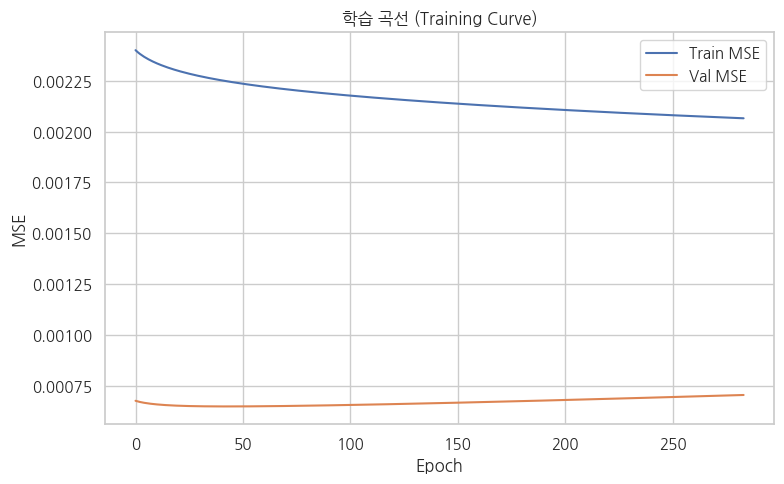

In [40]:
# ===== 5-3. 학습 곡선 시각화 =====
fig = tu.plot_training_curve(history)
fig.savefig(os.path.join(FIGURE_DIR, "04_training_curve.png"), dpi=150)
plt.show()


## 6. 모델 평가 및 지표 시각화 (Train / Val 기준)

R², RMSE, MAE 를 계산하고, 예측값-실제값 산점도 및 잔차 플롯으로 모델의 적합도를 확인합니다.
(Test 셋은 아직 사용하지 않습니다.)


In [41]:
# ===== 6-1. 지표 계산 (LinearRegression vs SGDRegressor) =====
rows = []
for name, model in [("LinearRegression", lr_model), ("SGDRegressor", sgd_model)]:
    train_metrics = tu.evaluate_regression(y_train, model.predict(X_train_scaled))
    val_metrics = tu.evaluate_regression(y_val, model.predict(X_val_scaled))
    rows.append({"model": name, "split": "train", **train_metrics})
    rows.append({"model": name, "split": "val", **val_metrics})

metrics_df = pd.DataFrame(rows)
display(metrics_df)


,model,split,R2,RMSE,MAE
0,LinearRegression,train,0.332406,0.040223,0.026777
1,LinearRegression,val,-0.748779,0.035566,0.029067
2,SGDRegressor,train,0.072869,0.047402,0.027249
3,SGDRegressor,val,0.104445,0.025452,0.018262


In [42]:
# ===== 6-2. 최종 베이스라인 모델 선택 =====
# 검증(val) 성능(R2)이 더 좋은 쪽을 최종 베이스라인으로 선택한다.
val_r2 = {
    "LinearRegression": tu.evaluate_regression(y_val, lr_model.predict(X_val_scaled))["R2"],
    "SGDRegressor": tu.evaluate_regression(y_val, sgd_model.predict(X_val_scaled))["R2"],
}
best_model_name = max(val_r2, key=val_r2.get)
best_model = lr_model if best_model_name == "LinearRegression" else sgd_model
print(f"검증 성능(R2) 기준 최종 선택 모델: {best_model_name}  (val R2 = {val_r2[best_model_name]:.4f})")


검증 성능(R2) 기준 최종 선택 모델: SGDRegressor  (val R2 = 0.1044)


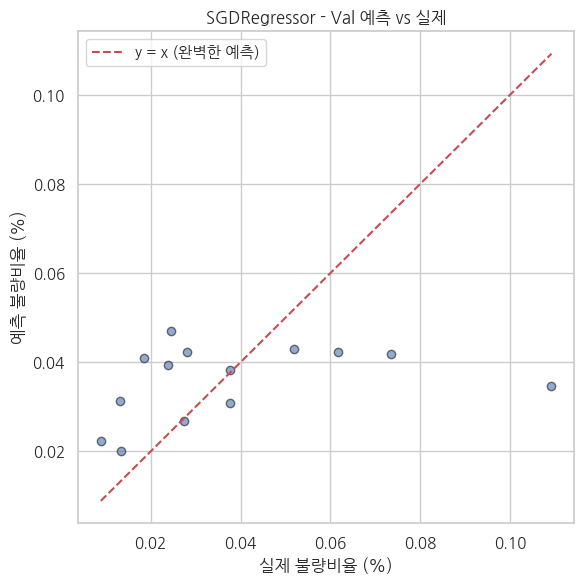

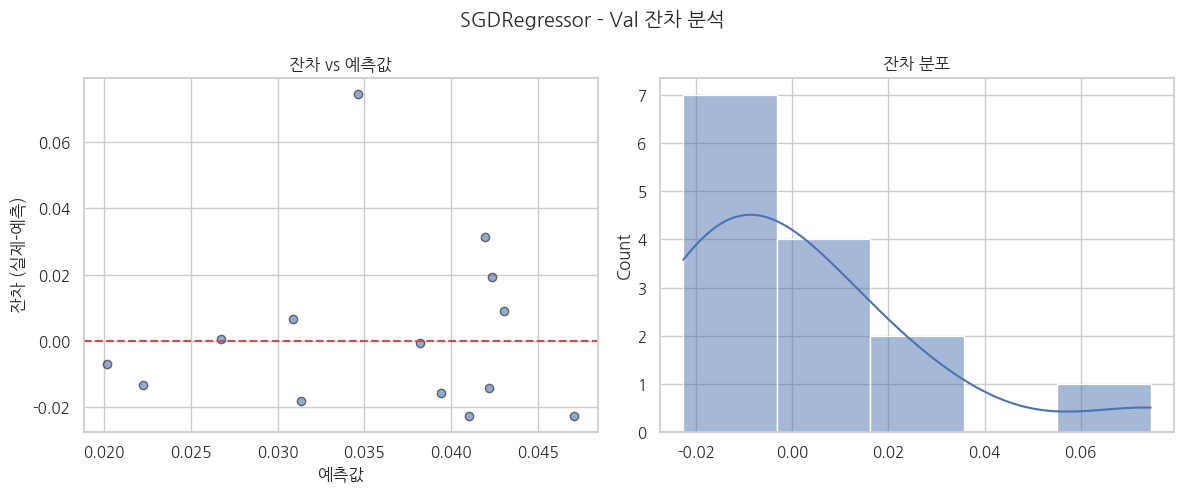

In [43]:
# ===== 6-3. 예측 vs 실제 / 잔차 플롯 (Val 기준) =====
val_pred = best_model.predict(X_val_scaled)

fig1 = tu.plot_pred_vs_actual(y_val.values, val_pred, title=f"{best_model_name} - Val 예측 vs 실제")
fig1.savefig(os.path.join(FIGURE_DIR, "05_val_pred_vs_actual.png"), dpi=150)
plt.show()

fig2 = tu.plot_residuals(y_val.values, val_pred, title=f"{best_model_name} - Val 잔차 분석")
fig2.savefig(os.path.join(FIGURE_DIR, "06_val_residuals.png"), dpi=150)
plt.show()


## ⚠️ 최종 테스트 평가 (Test set을 여는 유일한 셀)

여기까지 어떤 모델 선택/튜닝에도 `X_test`, `y_test` 를 사용하지 않았습니다.
아래 셀에서 **처음이자 마지막으로** test 세트를 열어 최종 일반화 성능을 확인합니다.
이 셀을 실행한 뒤에는 추가로 모델을 튜닝하지 않습니다 (그러면 test가 검증셋처럼 되어버려 의미가 없어짐).


[최종 테스트 성능] 모델=SGDRegressor
  R2: 0.0414
  RMSE: 0.0532
  MAE: 0.0334


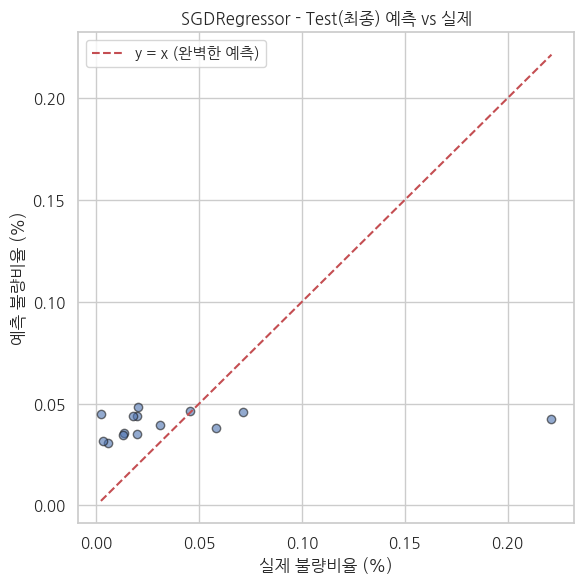

In [44]:
# ===== 최종 테스트 평가 =====
X_test_scaled = scaler.transform(X_test)   # train 에서 fit한 scaler를 그대로 재사용 (재적합 금지)
test_pred = best_model.predict(X_test_scaled)

test_metrics = tu.evaluate_regression(y_test, test_pred)
print(f"[최종 테스트 성능] 모델={best_model_name}")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

fig = tu.plot_pred_vs_actual(y_test.values, test_pred, title=f"{best_model_name} - Test(최종) 예측 vs 실제")
fig.savefig(os.path.join(FIGURE_DIR, "07_test_pred_vs_actual.png"), dpi=150)
plt.show()


## 7. 전체 EDA (모든 처리 완료 후) + Feature Importance

파이프라인 전체(비교 → 병합 → 전처리 → 분할 → 학습 → 평가)가 끝난 시점에서, 최종
데이터셋(`df_total`)에 대한 종합 EDA와 회귀계수 기반 Feature Importance를 확인합니다.


,count,mean,std,min,25%,50%,75%,max
배정번호,136.0,1.288972e+05,12403.393924,102410.000000,120467.750000,1.301990e+05,1.389825e+05,1.480690e+05
양품수량,136.0,4.501230e+04,25548.197992,8412.000000,29736.000000,4.400300e+04,6.012075e+04,1.047400e+05
불량수량,136.0,1.511765e+01,18.549657,0.000000,4.000000,8.500000e+00,1.700000e+01,1.200000e+02
불량비율,136.0,3.701311e-02,0.048175,0.000000,0.012746,2.196742e-02,4.564700e-02,3.685092e-01
Unnamed: 0_min,136.0,1.486001e+06,837160.651134,0.000000,785762.000000,1.487255e+06,2.192341e+06,2.913935e+06
건조 1존 OP_min,136.0,5.328268e+01,2.982164,47.253200,51.216725,5.300530e+01,5.455433e+01,7.125550e+01
건조 2존 OP_min,136.0,6.886595e+00,3.829835,0.000119,4.707825,6.879840e+00,8.718180e+00,2.846450e+01
건조로 온도 1 Zone_min,136.0,9.831553e+01,0.456637,97.342100,97.969275,9.822840e+01,9.861723e+01,9.943980e+01
건조로 온도 2 Zone_min,136.0,9.854095e+01,0.421257,97.870600,98.243400,9.849265e+01,9.873685e+01,9.967130e+01
세정기_min,136.0,6.626963e+01,1.682982,60.624400,65.168675,6.647945e+01,6.767068e+01,6.904930e+01


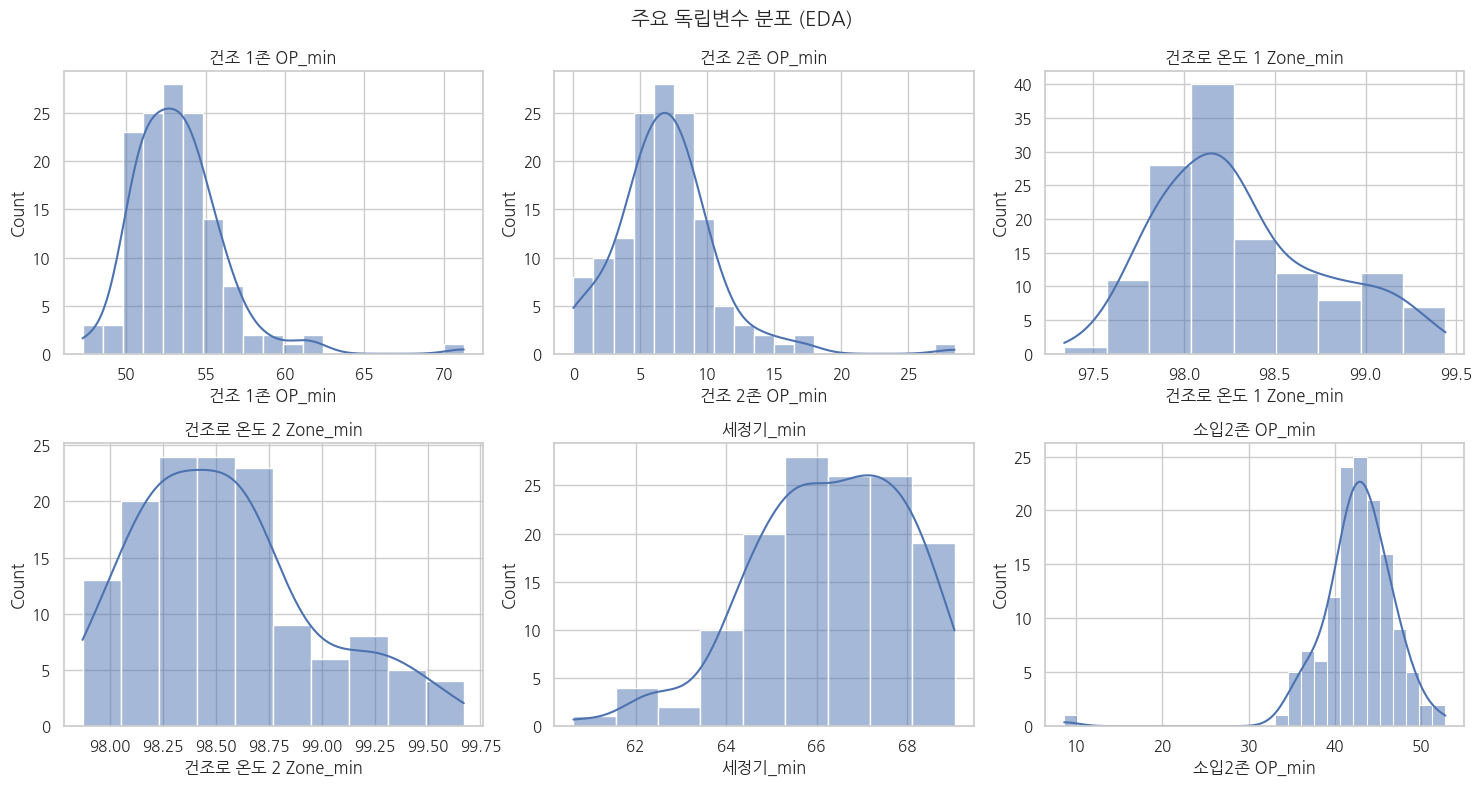

In [45]:
# ===== 7-1. 최종 데이터셋 기초 통계 / 분포 =====
display(df_total.describe().T)

# 최종적으로 사용된 독립변수 중 상위 6개 변수의 분포를 확인
top_features = X_reduced.columns[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), top_features):
    sns.histplot(df_total[col], kde=True, ax=ax)
    ax.set_title(col)
fig.suptitle("주요 독립변수 분포 (EDA)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "08_feature_distributions.png"), dpi=150)
plt.show()


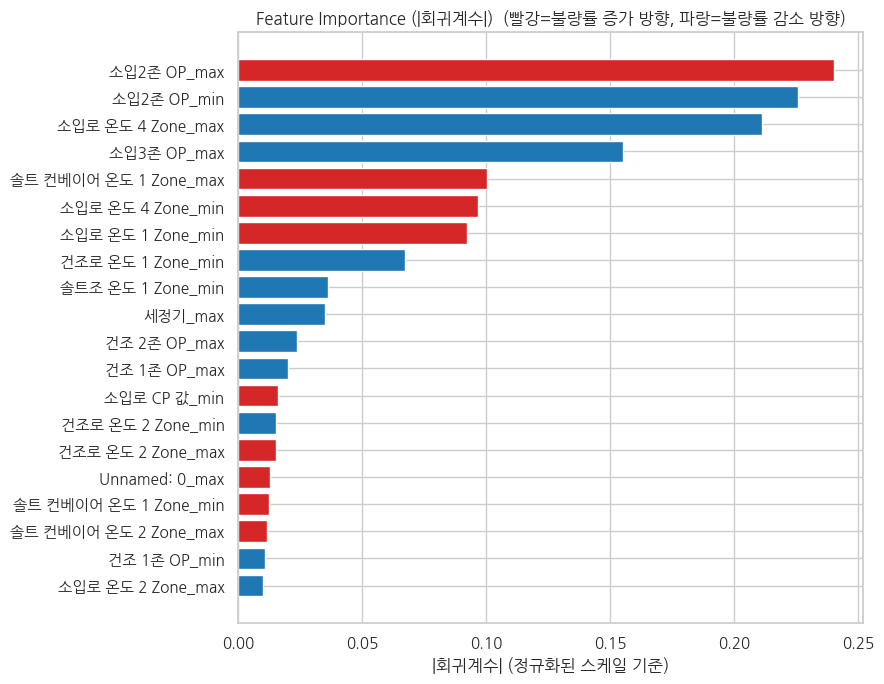

,feature,coef,abs_coef
0,소입2존 OP_max,0.239990,0.239990
1,소입2존 OP_min,-0.225579,0.225579
2,소입로 온도 4 Zone_max,-0.211084,0.211084
3,소입3존 OP_max,-0.155090,0.155090
4,솔트 컨베이어 온도 1 Zone_max,0.100317,0.100317
5,소입로 온도 4 Zone_min,0.096952,0.096952
6,소입로 온도 1 Zone_min,0.092488,0.092488
7,건조로 온도 1 Zone_min,-0.067156,0.067156
8,솔트조 온도 1 Zone_min,-0.036303,0.036303
9,세정기_max,-0.035126,0.035126


In [46]:
# ===== 7-2. Feature Importance (선형회귀 계수 기반) =====
# 계수는 LinearRegression 기준으로 계산한다 (해석이 더 직관적인 closed-form 모델).
fig = tu.plot_feature_importance(feature_names, lr_model.coef_, top_n=20)
fig.savefig(os.path.join(FIGURE_DIR, "09_feature_importance.png"), dpi=150)
plt.show()

importance_table = (
    pd.DataFrame({"feature": feature_names, "coef": lr_model.coef_})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)
display(importance_table)
importance_table.to_csv(os.path.join(PROCESSED_DIR, "feature_importance.csv"), index=False, encoding="utf-8-sig")


## 8. 결론 및 다음 단계 (요약 메모)

- 데이터 요약: raw_total_data.csv(약 294만 행) → 배정번호 단위 집계 → label 병합 → 최종 `df_total`
  (136행, 다중공선성 제거 후 X개 독립변수)
- 베이스라인 모델: 선형회귀(Linear/SGD), Test R2 = (위 셀 결과 참고)
- 다음 단계 아이디어:
  - Ridge/Lasso 등 정규화 회귀와 비교
  - DecisionTree/RandomForest 등 비선형 모델과 비교 (가이드북 참고)
  - 배정번호별 시계열 특성(구간별 평균/표준편차 등) 추가 파생변수 실험
  - 데이터가 136건으로 적으므로 K-Fold 교차검증으로 안정성 재확인
